#### Base de dados (tabela DN)
https://datasus.saude.gov.br/transferencia-de-arquivos


<h1 align="center">Predição do peso ao nascer em Minas Gerais utilizando modelos de regressão a partir dos dados da SINASC</h1>

---

## Problema

Predizer o risco de baixo peso ao nascer (<2500g) em nascidos vivos em Minas Gerais no período de 2020-2024, utilizando dados socioeconômicos e clínicos disponíveis até o momento do parto com dados da base SINASC da tabela DN.  

É um problema de regressão, com base clínica sólida na literatura (fator de risco reconhecido para mortalidade neonatal), desbalanceamento de classes (~8-10% de baixo peso no Brasil).

## Escopo

| Parâmetro | Definição |
|---|---|
| **Fonte** | SINASC (tabela DN)
| **UF** | Minas Gerais (MG) |
| **Período** | 2020–2024 (5 anos) |
| **Unidade de análise** | 1 registro = 1 nascido vivo |
| **Target** | `PESO < 2500`|

---

### Importando bibliotecas

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from datetime import datetime
import os

### Lendo os arquivos

In [3]:
# Todos os arquivos csv da pasta data
arquivos_csv = [f for f in os.listdir('data') if f.endswith('.csv')]

dfs = []
for arquivo in arquivos_csv:
    path = os.path.join('data', arquivo)
    df = pd.read_csv(path)
    df['origem'] = arquivo
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
df.head()

C:\Users\Max\AppData\Local\Temp\ipykernel_14372\3530333382.py:7: DtypeWarning: Columns (32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


,ORIGEM,CODESTAB,CODMUNNASC,LOCNASC,IDADEMAE,ESTCIVMAE,ESCMAE,CODOCUPMAE,QTDFILVIVO,QTDFILMORT,...,DTDECLARAC,ESCMAEAGR1,STDNEPIDEM,STDNNOVA,CODPAISRES,TPROBSON,PARIDADE,KOTELCHUCK,CONTADOR,origem
0,1,2495228.0,110028,1,19,2.0,4.0,621005.0,1.0,3.0,...,12012020.0,6.0,0,1,1,11,1,4,10480,DNMG2020.csv
1,1,2456613.0,210530,1,21,1.0,5.0,999991.0,0.0,0.0,...,1022020.0,7.0,0,1,1,2,0,2,169378,DNMG2020.csv
2,1,2456893.0,211130,1,29,1.0,5.0,999991.0,1.0,1.0,...,NaN,7.0,0,1,1,3,1,5,194775,DNMG2020.csv
3,1,6553567.0,211230,1,32,2.0,4.0,621005.0,1.0,0.0,...,10042020.0,5.0,0,1,1,5,1,5,198579,DNMG2020.csv
4,1,2319454.0,260790,1,25,1.0,4.0,999992.0,1.0,0.0,...,7012020.0,12.0,0,1,1,5,1,2,357523,DNMG2020.csv


In [4]:
# Filtrandos as features que serão utilizadas
filtro = ['IDADEMAE', 
          'ESTCIVMAE', 
          'ESCMAE2010', 
          'QTDFILVIVO', 
          'QTDFILMORT', 
          'QTDGESTANT', 
          'QTDPARTNOR', 
          'QTDPARTCES', 
          'PARIDADE', 
          'GRAVIDEZ', 
          'SEMAGESTAC', 
          'KOTELCHUCK', 
          'CONSPRENAT', 
          'MESPRENAT', 
          'SEXO', 
          'DTNASC',
          'PESO'] # <- Target

df = df[filtro]

In [5]:
# Sumario das variáveis
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1178134 entries, 0 to 1178133
Data columns (total 17 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   IDADEMAE    1178134 non-null  int64  
 1   ESTCIVMAE   1172467 non-null  float64
 2   ESCMAE2010  1169266 non-null  float64
 3   QTDFILVIVO  1166936 non-null  float64
 4   QTDFILMORT  1163351 non-null  float64
 5   QTDGESTANT  1164011 non-null  float64
 6   QTDPARTNOR  1161668 non-null  float64
 7   QTDPARTCES  1161530 non-null  float64
 8   PARIDADE    1178134 non-null  int64  
 9   GRAVIDEZ    1177452 non-null  float64
 10  SEMAGESTAC  1168427 non-null  float64
 11  KOTELCHUCK  1178134 non-null  int64  
 12  CONSPRENAT  1164948 non-null  float64
 13  MESPRENAT   1157142 non-null  float64
 14  SEXO        1178134 non-null  int64  
 15  DTNASC      1178134 non-null  int64  
 16  PESO        1178100 non-null  float64
dtypes: float64(12), int64(5)
memory usage: 152.8 MB


Podemos ver os tipos das variáveis e que também há dados nulos.

### Verificando dados nulos

In [6]:
display(df.isnull().sum().sum(), df.isnull().sum())

np.int64(132310)

IDADEMAE          0
ESTCIVMAE      5667
ESCMAE2010     8868
QTDFILVIVO    11198
QTDFILMORT    14783
QTDGESTANT    14123
QTDPARTNOR    16466
QTDPARTCES    16604
PARIDADE          0
GRAVIDEZ        682
SEMAGESTAC     9707
KOTELCHUCK        0
CONSPRENAT    13186
MESPRENAT     20992
SEXO              0
DTNASC            0
PESO             34
dtype: int64

Nosso dataframe tem 132310 dados nulos, cada coluna deve ser tratada individualmente.

In [7]:
# Sumario das variáveis  
df.describe().apply(lambda s: s.apply('{:.2f}'.format))
#             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^ desativa anotação cientifica

,IDADEMAE,ESTCIVMAE,ESCMAE2010,QTDFILVIVO,QTDFILMORT,QTDGESTANT,QTDPARTNOR,QTDPARTCES,PARIDADE,GRAVIDEZ,SEMAGESTAC,KOTELCHUCK,CONSPRENAT,MESPRENAT,SEXO,DTNASC,PESO
count,1178134.00,1172467.00,1169266.00,1166936.00,1163351.00,1164011.00,1161668.00,1161530.00,1178134.00,1177452.00,1168427.00,1178134.00,1164948.00,1157142.00,1178134.00,1178134.00,1178100.00
mean,28.16,1.89,3.28,0.90,0.25,1.14,0.54,0.38,0.61,1.03,38.30,4.63,9.10,4.36,1.49,15746489.03,3117.40
std,6.66,1.23,1.06,1.11,0.62,1.33,1.05,0.70,0.49,0.16,2.18,1.36,4.98,14.13,0.50,8772539.60,549.76
min,10.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,19.00,1.00,0.00,1.00,0.00,1012020.00,100.00
25%,23.00,1.00,3.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,38.00,5.00,7.00,1.00,1.00,8072022.00,2850.00
50%,28.00,2.00,3.00,1.00,0.00,1.00,0.00,0.00,1.00,1.00,39.00,5.00,9.00,2.00,1.00,16022024.00,3160.00
75%,33.00,2.00,4.00,1.00,0.00,2.00,1.00,1.00,1.00,1.00,39.00,5.00,10.00,3.00,2.00,23092022.00,3455.00
max,99.00,9.00,9.00,99.00,99.00,99.00,99.00,99.00,1.00,9.00,45.00,9.00,99.00,99.00,2.00,31122024.00,7000.00


In [8]:
# Preenchendo os valores nulos com a mediana
for col in df.columns:
    df.loc[df[col].isna(), col] = df[col].median()

In [9]:
# Avaliando a quantidade de dados duplicados
df[df.duplicated()]

,IDADEMAE,ESTCIVMAE,ESCMAE2010,QTDFILVIVO,QTDFILMORT,QTDGESTANT,QTDPARTNOR,QTDPARTCES,PARIDADE,GRAVIDEZ,SEMAGESTAC,KOTELCHUCK,CONSPRENAT,MESPRENAT,SEXO,DTNASC,PESO
1107,33,2.0,5.0,0.0,0.0,0.0,0.0,0.0,0,2.0,33.0,5,9.0,1.0,1,17022020,1835.0
2852,34,2.0,5.0,1.0,0.0,1.0,0.0,1.0,1,2.0,36.0,5,14.0,2.0,2,3012020,2430.0
4585,36,5.0,3.0,3.0,1.0,4.0,3.0,0.0,1,1.0,39.0,9,4.0,99.0,2,28042020,4165.0
5831,28,2.0,3.0,1.0,0.0,1.0,1.0,0.0,1,1.0,39.0,5,11.0,1.0,2,9022020,3490.0
24560,28,1.0,5.0,0.0,0.0,0.0,0.0,0.0,0,1.0,37.0,5,7.0,2.0,2,14052020,2125.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138212,20,1.0,3.0,1.0,0.0,1.0,0.0,1.0,1,3.0,30.0,2,8.0,4.0,2,18082024,1320.0
1142592,42,2.0,5.0,2.0,2.0,4.0,0.0,2.0,1,1.0,39.0,5,7.0,1.0,1,16082024,3975.0
1145174,34,2.0,5.0,1.0,0.0,1.0,0.0,1.0,1,1.0,38.0,5,7.0,2.0,1,17082024,3210.0
1170932,33,2.0,5.0,0.0,0.0,0.0,0.0,0.0,0,2.0,36.0,5,11.0,1.0,1,26072024,2260.0


In [10]:
# Verificando a proporção das variáveis de classe
display(round(df['ESTCIVMAE'].value_counts(normalize=True)*100, 2), 
        round(df['ESCMAE2010'].value_counts(normalize=True)*100,2), 
        round(df['GRAVIDEZ'].value_counts(normalize=True)*100,2), 
        round(df['SEXO'].value_counts(normalize=True)*100, 2))

ESTCIVMAE
1.0    45.92
2.0    42.07
5.0     9.37
4.0     2.15
9.0     0.28
3.0     0.22
Name: proportion, dtype: float64

ESCMAE2010
3.0    56.48
5.0    20.92
2.0    15.63
4.0     4.84
1.0     1.83
9.0     0.17
0.0     0.12
Name: proportion, dtype: float64

GRAVIDEZ
1.0    97.51
2.0     2.42
3.0     0.06
9.0     0.00
Name: proportion, dtype: float64

SEXO
1    51.13
2    48.86
0     0.01
Name: proportion, dtype: float64

A proporção das classes, principalmente aquelas que informam a quantidade ignorada, está proporcionalmente baixas.

Vamos ver como está a distribuição da variável **target**:

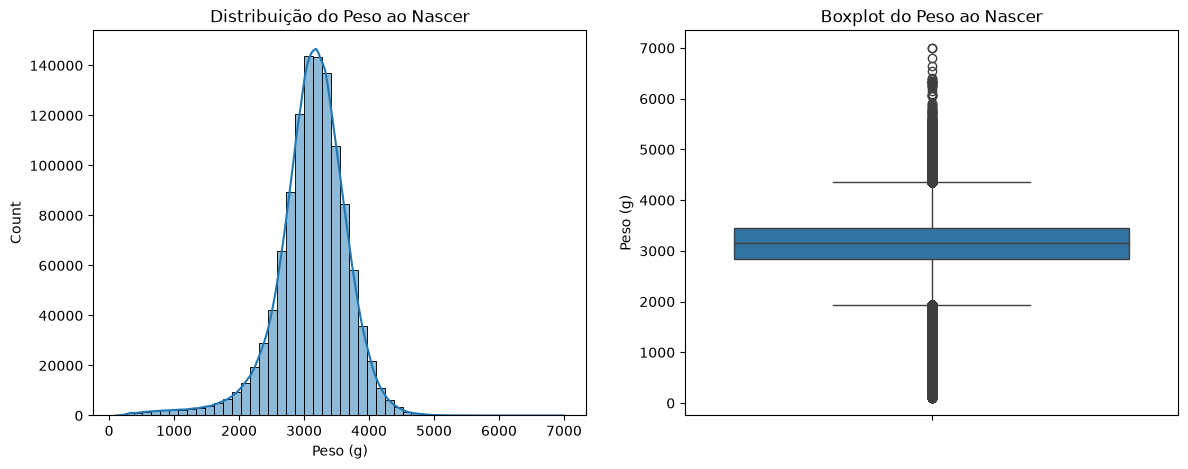

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma com curva de densidade
sns.histplot(df['PESO'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribuição do Peso ao Nascer')
axes[0].set_xlabel('Peso (g)')

# Boxplot para visualizar outliers
sns.boxplot(y=df['PESO'], ax=axes[1])
axes[1].set_title('Boxplot do Peso ao Nascer')
axes[1].set_ylabel('Peso (g)')

plt.show()

Podemos ver que de fato a média do peso está por volta de 3100 gramas, com valores relativamente concentrados. Entretanto, existe valores para peso inferior a 500g e superior a 6000g, fora da literatura clinica, portanto são dados que devem estar sendo removidos do dataset.

Além disso, podemos ver a proporção de crianças abaixo de 2500g, segundo a taxa nacional, ela deve estar entre 8 a 10%.

In [12]:
# Proporção entre 8 a 10%
round((df['PESO'].shape[0]/ df[df['PESO'] < 2500].shape[0]), 2)

10.02

A proporção de crianças de MG abaixo de 2500g está entre a média nacional.

Verficando se o período de pandemia alterou as distribuições:

In [ ]:
# Convertendo a data de nascimento para o tipo datetime
df['DTNASC'] = pd.to_datetime(df['DTNASC'], format='%d%m%Y', errors='coerce')

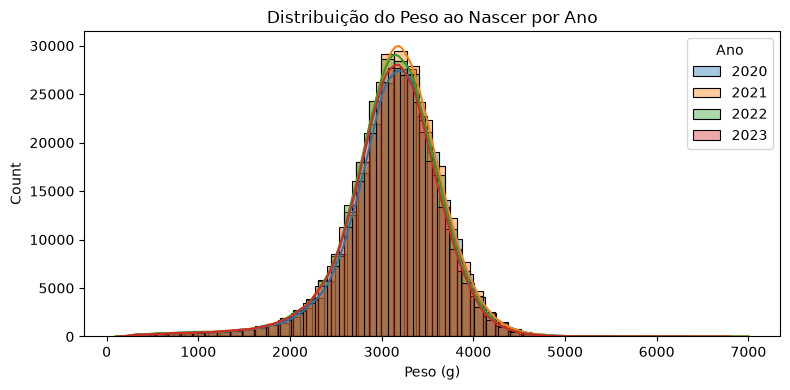

In [ ]:
# Desenhando os gráficos
fig, ax = plt.subplots(figsize=(8, 4))

anos = [2020, 2021, 2022, 2023, 2024]
cores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for ano, cor in zip(anos, cores):
    dados = df[(df['DTNASC'] >= f'{ano}-01-01') & (df['DTNASC'] <= f'{ano}-12-31')]['PESO']
    sns.histplot(dados, bins=50, kde=True, ax=ax, color=cor, label=str(ano), alpha=0.4)

ax.set_title('Distribuição do Peso ao Nascer por Ano')
ax.set_xlabel('Peso (g)')
ax.legend(title='Ano')

plt.tight_layout()
plt.show()

Pelas sobreposições dos gráficos, as distribuições permaneceram a mesma.

## **Distribuições**

Vamos explorar as distribuições de cada tipo de variável

### Categóricas

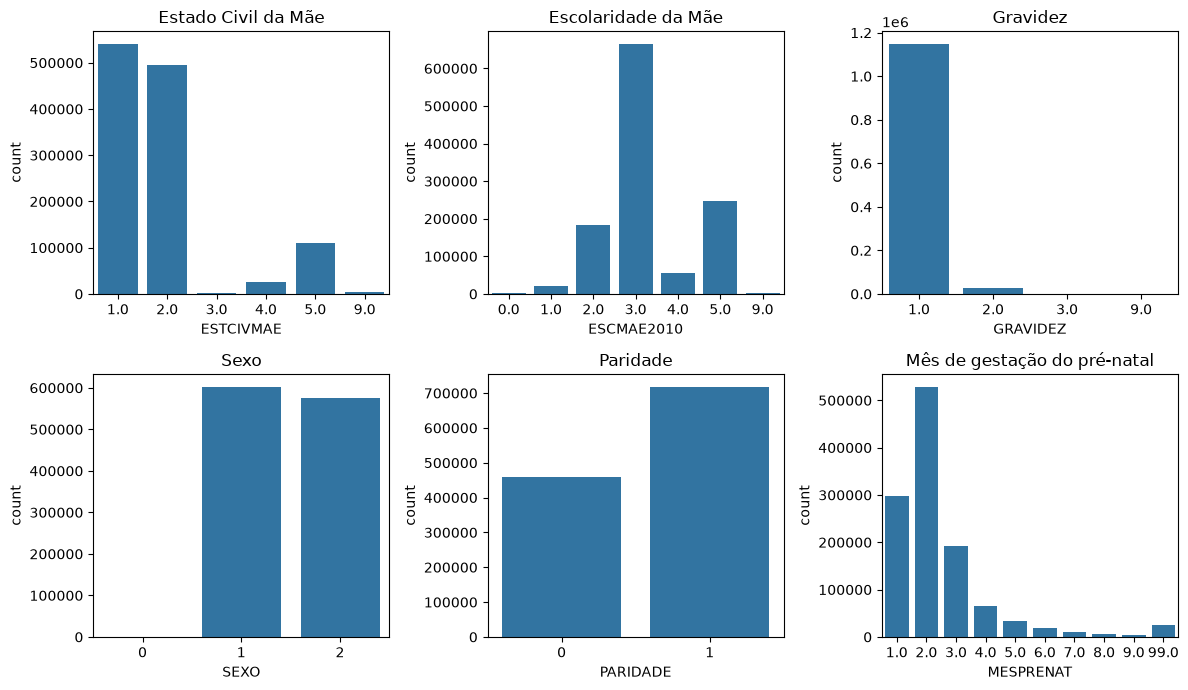

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

sns.countplot(x=df['ESTCIVMAE'], ax=axes[0,0])
axes[0,0].set_title('Estado Civil da Mãe')

sns.countplot(x=df['ESCMAE2010'], ax=axes[0,1])
axes[0,1].set_title('Escolaridade da Mãe')

sns.countplot(x=df['GRAVIDEZ'], ax=axes[0,2])
axes[0,2].set_title('Gravidez')

sns.countplot(x=df['SEXO'], ax=axes[1,0])
axes[1,0].set_title('Sexo')

sns.countplot(x=df['PARIDADE'], ax=axes[1,1])
axes[1,1].set_title('Paridade')

sns.countplot(x=df['MESPRENAT'], ax=axes[1,2])
axes[1,2].set_title('Mês de gestação do pré-natal')

plt.tight_layout()
plt.show()

### **Conclusões:**
- **Estado Civil da Mãe:** Concentração forte em 1 (Solteira) e 2 (Casada), ambas dominam o dataset. 5 (União estável) tem um volume relevante.
- **Escolaridade da Mãe:** Bem definido em 3 (Ensino Médio) com mais de 600 mil registros, seguido por superior completo.
- **Gravidez:** A maior parte concentrada em única. Gravidez múltiplca é uma fração muito pequeno da amostra. É uma classe desbalanceada dentro do dataset.
- **Sexo:** Distribuição esperada, aproximadamente 50% para ambas as categorias.
- **Paridade:** Distribuição bem equilibrada também.
- **Mês de gestação em que iniciou o pré-natal:** Concetração muito forte nos dois primeiros meses, um começo precoce é bem positivo para saúde pública, caindo de forma consistente até o mês 9. Categoria de ignorado (99) bem forte

### Numéricas

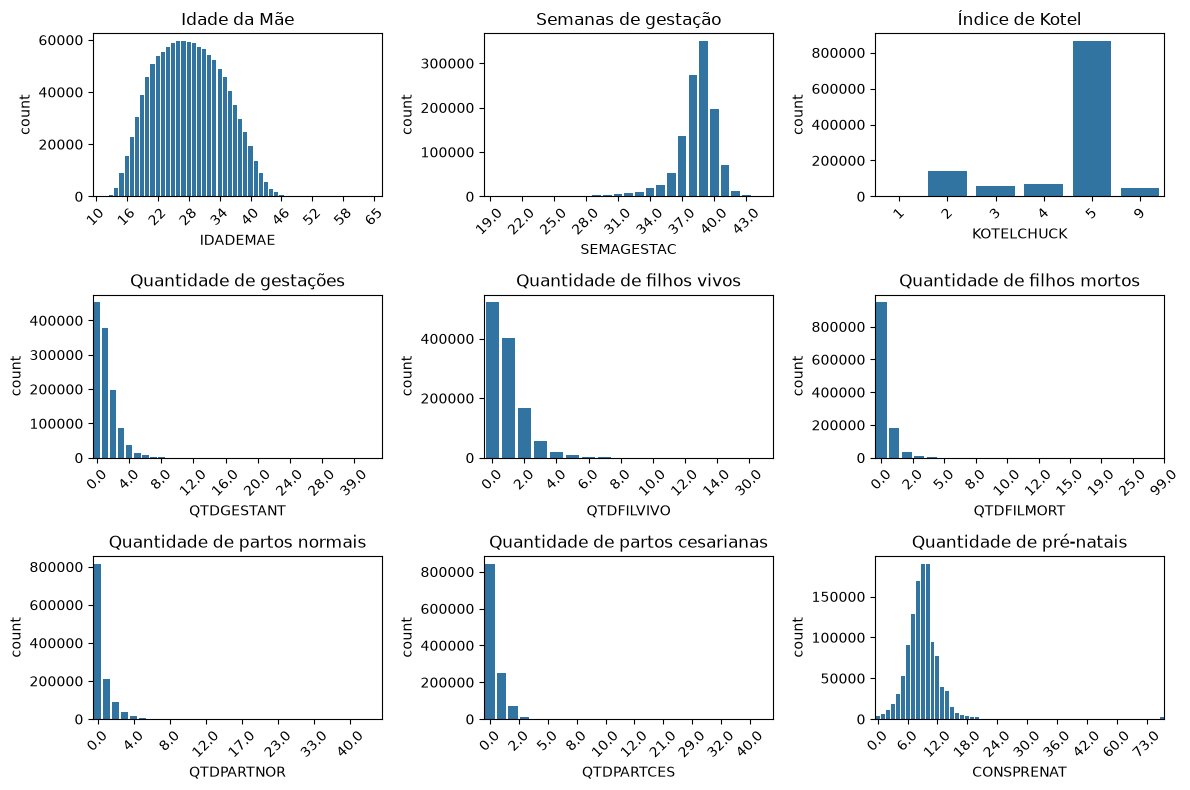

In [48]:
fig, axes = plt.subplots(3, 3, figsize=(12, 8))

colunas_titulos = {
    'IDADEMAE': 'Idade da Mãe',
    'SEMAGESTAC': 'Semanas de gestação',
    'KOTELCHUCK': 'Índice de Kotel',
    'QTDGESTANT': 'Quantidade de gestações',
    'QTDFILVIVO': 'Quantidade de filhos vivos',
    'QTDFILMORT': 'Quantidade de filhos mortos',
    'QTDPARTNOR': 'Quantidade de partos normais',
    'QTDPARTCES': 'Quantidade de partos cesarianas',
    'CONSPRENAT': 'Quantidade de pré-natais',
}

for ax, (coluna, titulo) in zip(axes.flat, colunas_titulos.items()):
    sns.countplot(x=df[coluna], ax=ax)
    ax.set_title(titulo)
    if coluna == 'KOTELCHUCK':
        ax.xaxis.set_major_locator(ticker.MaxNLocator(6))
    else:
        ax.xaxis.set_major_locator(ticker.MaxNLocator(10))
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### **Conclusões:**
- **Idade da Mãe:** Distribuição comportada, formato de sino suavemente assimétrico à direita, com média de 24 à 28 anos, dentro do escopo esperado, avaliar extremos menor que 10 e maior que 65.
- **Semanas de Gestação:** Concentração forte em 37 à 40 semanas, com uma cauda suave até 28. Formato esperado clinicamente.
- **Índice de Kotelchuck:** Concentrado na categoria 5, indica um bom sinal de qualidade assistencial na base.
- **Quantidade de Gestações:** Fortemente concentrado em 0 à 2, padrão esperado. Avaliar valores acima de 15 gestações.
- **Quantidade de Filhos Vivos:** Concentração em 0-1, cauda até 30, avaliar os extremos.
- **Quantidade de Filhos Mortos:** Avaliar valores extremos.
- **Quantidade de Partos Normais/Cesáreos:** Forte concentração em 0 à 1.
- **Quantidade de Consultas Pré-natal:** Distribuição aproximadamente normal, concetrada em 6-9 consultas. Coerente com a recomendação de pré-natal adequado. Avaliar caudas extremas.